# feature_evaluation.ipynb
Explores whether each feature is worth keeping before training begins. Produces target-correlation charts, inter-feature redundancy heatmaps, engineered-feature value comparisons, and distribution plots.

In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, matthews_corrcoef

from features import engineer_features, get_feature_columns, get_target_column
from models import build_model, get_class_weight

sns.set_theme(style='darkgrid')

df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df = engineer_features(df)

features = get_feature_columns()
X = df[features]
y: pd.Series = df[get_target_column()]

print(f'Rows:     {len(df)} (after RNF removal)')
print(f'Features: {features}')
print(f'Failures: {y.sum()} / {len(y)} ({y.mean()*100:.1f}%)')
print()
print('Note: power_kW = torque × RPM / 9550 (kilowatts, not watts)')


Dropped 19 RNF rows (10000 → 9981)
Rows:     9981 (after RNF removal)
Features: ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min', 'power_kW', 'temp_delta_K', 'torque_wear', 'product_type']
Failures: 338 / 9981 (3.4%)

Note: power_kW = torque × RPM / 9550 (kilowatts, not watts)


## 1 · Feature–target correlation

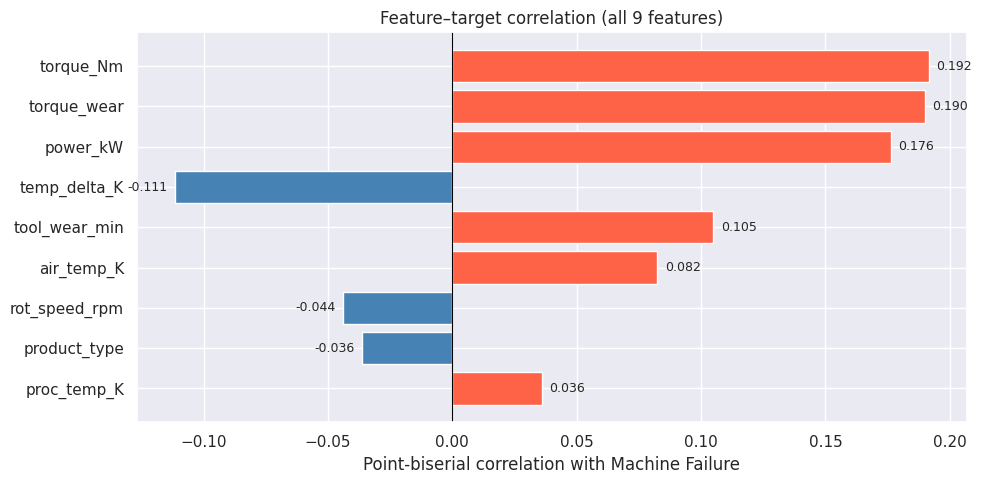

      Feature  Correlation             Direction
    torque_Nm       0.1916 Higher → more failure
  torque_wear       0.1900 Higher → more failure
     power_kW       0.1764 Higher → more failure
 temp_delta_K      -0.1115  Lower → more failure
tool_wear_min       0.1050 Higher → more failure
   air_temp_K       0.0824 Higher → more failure
rot_speed_rpm      -0.0440  Lower → more failure
 product_type      -0.0364  Lower → more failure
  proc_temp_K       0.0359 Higher → more failure


In [ ]:
# Q: How strongly does each feature correlate with failure?
correlations = {}
for col in features:
    r, p = stats.pointbiserialr(y, X[col])
    correlations[col] = r

corr_s = pd.Series(correlations).sort_values(key=abs, ascending=True)
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_s.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr_s.index, corr_s.to_numpy().astype(float), color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Point-biserial correlation with Machine Failure')
ax.set_title(f'Feature-target correlation (all {len(features)} features)')
for i, (val, name) in enumerate(zip(corr_s.values, corr_s.index)):
    ax.text(float(val) + (0.003 if val >= 0 else -0.003), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feat_eval_target_corr.png', dpi=150)
plt.show()

corr_table = pd.DataFrame({
    'Feature': corr_s.index.tolist(),
    'Correlation': corr_s.round(4).tolist(),
    'Direction': ['Higher -> more failure' if v > 0 else 'Lower -> more failure' for v in corr_s.values],
}).iloc[::-1]
print(corr_table.to_string(index=False))

## 2 · Inter-feature redundancy

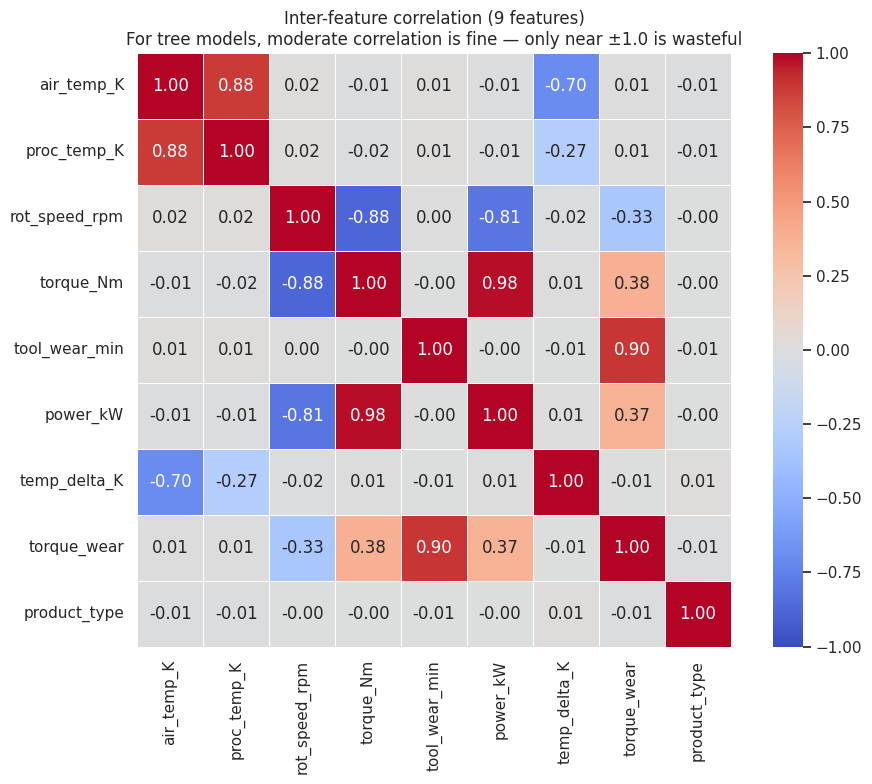

In [ ]:
# Q: Are any features redundant with each other?
# For tree models, moderate correlation is fine — only near +/-1.0 is wasteful.
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title(
    f'Inter-feature correlation ({len(features)} features)\n'
    'For tree models, moderate correlation is fine — only near +/-1.0 is wasteful'
)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feat_eval_redundancy.png', dpi=150)
plt.show()

## 3 · Value of engineered features

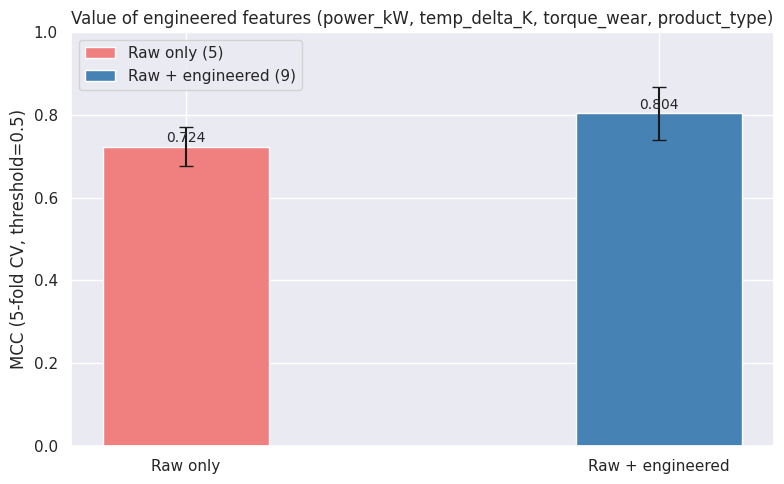

MCC improvement from engineered features: +0.0803


In [ ]:
# Q: Do the engineered features add value beyond raw sensors?
raw_cols = ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min']
all_cols = get_feature_columns()

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)
weight     = get_class_weight(y)

X_raw = np.asarray(X[raw_cols])
X_all = np.asarray(X[all_cols])
mcc_raw = cross_val_score(build_model(scale_pos_weight=weight), X_raw, y, cv=skf, scoring=mcc_scorer)
mcc_all = cross_val_score(build_model(scale_pos_weight=weight), X_all, y, cv=skf, scoring=mcc_scorer)

fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(2), 0.35
b1 = ax.bar(x[0], mcc_raw.mean(), w, yerr=mcc_raw.std(), capsize=5,
            color='lightcoral', label=f'Raw only ({len(raw_cols)})')
b2 = ax.bar(x[1], mcc_all.mean(), w, yerr=mcc_all.std(), capsize=5,
            color='steelblue', label=f'Raw + engineered ({len(all_cols)})')
ax.set_xticks(x)
ax.set_xticklabels(['Raw only', 'Raw + engineered'])
ax.set_ylabel('MCC (5-fold CV, threshold=0.5)')
ax.set_ylim(0, 1)
ax.set_title('Value of engineered features (power_kW, temp_delta_K, torque_wear, product_type)')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feat_eval_raw_vs_eng.png', dpi=150)
plt.show()

print(f'MCC improvement from engineered features: {mcc_all.mean() - mcc_raw.mean():+.4f}')

## 4 · Feature distributions: failure vs no failure

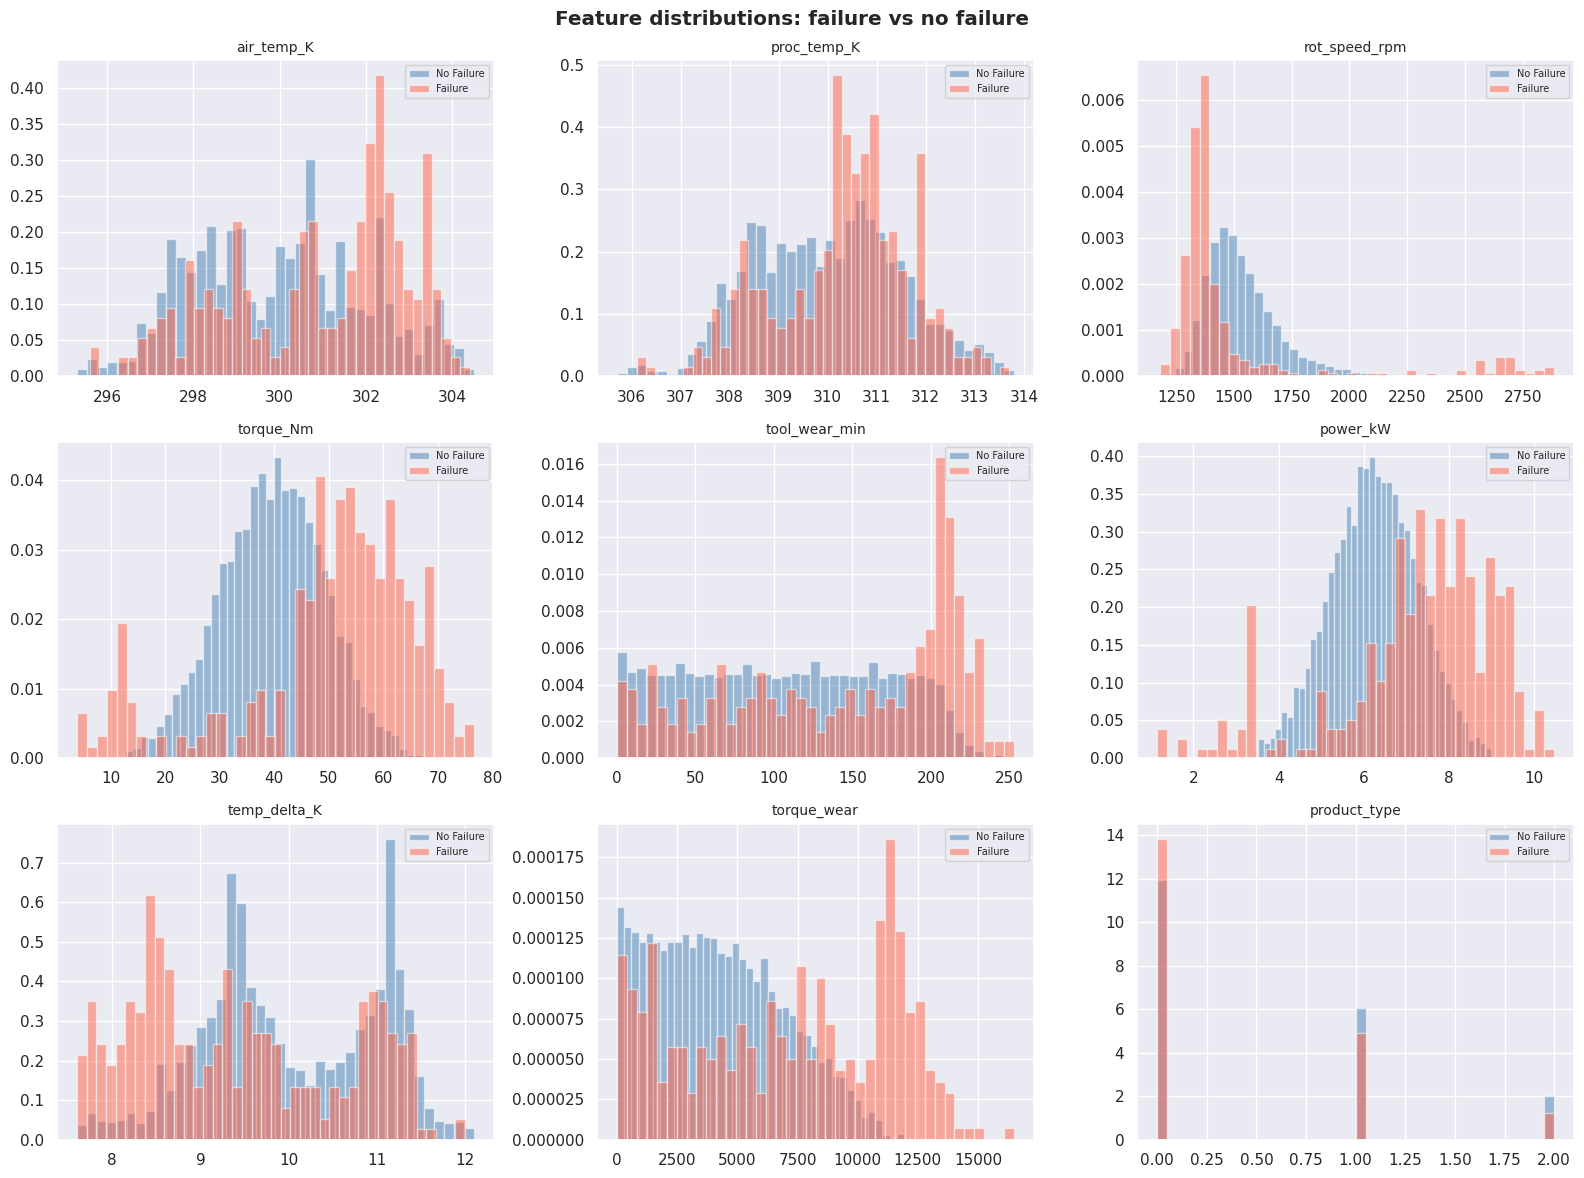

In [ ]:
# Q: How do failure vs no-failure distributions differ for each feature?
n_feats = len(features)
n_cols  = 4
n_rows  = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flatten()

nf = X[y == 0]
f  = X[y == 1]

for i, col in enumerate(features):
    ax = axes_flat[i]
    ax.hist(nf[col], bins=40, alpha=0.5, density=True, color='steelblue', label='No Failure')
    ax.hist(f[col],  bins=40, alpha=0.5, density=True, color='tomato',    label='Failure')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(n_feats, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature distributions: failure vs no failure', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feat_eval_distributions.png', dpi=150)
plt.show()